# Traffic Accident Analysis - CSE 532 Final Project

## Research Question
**In this project, we aim to investigate whether weather conditions and road characteristics influence accident severity using real-world US traffic accident data.**

---

## Part 1: Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Part 2: Download Dataset from Kaggle

In [2]:
import kagglehub
import os

print("Downloading US Accidents dataset from Kaggle...")
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents", output_dir="../data/")
print(f"✓ Dataset downloaded to: {path}")

# find csv file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(f"\nCSV files found: {csv_files}")
dataset_file = os.path.join(path, csv_files[0])
print(f"Using: {csv_files[0]}")

✓ Dataset downloaded to: ../data/

CSV files found: ['US_Accidents_March23.csv']
Using: US_Accidents_March23.csv


## Part 3: Load Dataset

In [3]:
print("Loading dataset...")
df = pd.read_csv(dataset_file, nrows=1000000)  # Load only the first 1 million rows for efficiency

print(f" * Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"  - Rows (accidents): {df.shape[0]:,}")
print(f"  - Columns (features): {df.shape[1]}")

Loading dataset...
 * Dataset loaded successfully!

Dataset Shape: (1000000, 46)
  - Rows (accidents): 1,000,000
  - Columns (features): 46


In [4]:
print("\nDataset Columns and types:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}: {df[col].dtype}")

print("\nSample of the dataset:")
print(df.head())


Dataset Columns and types:
   1. ID: str
   2. Source: str
   3. Severity: int64
   4. Start_Time: str
   5. End_Time: str
   6. Start_Lat: float64
   7. Start_Lng: float64
   8. End_Lat: float64
   9. End_Lng: float64
  10. Distance(mi): float64
  11. Description: str
  12. Street: str
  13. City: str
  14. County: str
  15. State: str
  16. Zipcode: str
  17. Country: str
  18. Timezone: str
  19. Airport_Code: str
  20. Weather_Timestamp: str
  21. Temperature(F): float64
  22. Wind_Chill(F): float64
  23. Humidity(%): float64
  24. Pressure(in): float64
  25. Visibility(mi): float64
  26. Wind_Direction: str
  27. Wind_Speed(mph): float64
  28. Precipitation(in): float64
  29. Weather_Condition: str
  30. Amenity: bool
  31. Bump: bool
  32. Crossing: bool
  33. Give_Way: bool
  34. Junction: bool
  35. No_Exit: bool
  36. Railway: bool
  37. Roundabout: bool
  38. Station: bool
  39. Stop: bool
  40. Traffic_Calming: bool
  41. Traffic_Signal: bool
  42. Turning_Loop: bool
  43. 

## Part 4: Missing Values Analysis

In [5]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

print("Columns with Missing Values:")
print("="*80)
missing_with_gaps = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_with_gaps) > 0:
    for idx, row in missing_with_gaps.iterrows():
        pct_str = f"{row['Missing_Percentage']:.2f}%"
        print(f"{row['Column']:30s} | Count: {row['Missing_Count']:>10,d} | {pct_str:>8s}")
else:
    print("No missing values!")

print(f"\nTotal columns with missing data: {len(missing_with_gaps)}")

Columns with Missing Values:
End_Lng                        | Count:  1,000,000 |  100.00%
End_Lat                        | Count:  1,000,000 |  100.00%
Precipitation(in)              | Count:    475,316 |   47.53%
Wind_Chill(F)                  | Count:    460,589 |   46.06%
Wind_Speed(mph)                | Count:    100,398 |   10.04%
Visibility(mi)                 | Count:     18,931 |    1.89%
Weather_Condition              | Count:     18,211 |    1.82%
Humidity(%)                    | Count:     16,553 |    1.66%
Temperature(F)                 | Count:     15,298 |    1.53%
Wind_Direction                 | Count:     13,570 |    1.36%
Pressure(in)                   | Count:     12,376 |    1.24%
Weather_Timestamp              | Count:      9,927 |    0.99%
Street                         | Count:      1,712 |    0.17%
Civil_Twilight                 | Count:      1,636 |    0.16%
Astronomical_Twilight          | Count:      1,636 |    0.16%
Nautical_Twilight              | Count:  

## Part 5: Data Cleaning Strategy

We will keep most columns untouched and only fix the missing values that matter for the analysis:
- `End_Lat` and `End_Lng`: fill from the start location when missing
- `Precipitation(in)`: fill with 0 when missing

- Remove unwanted columns:
    - Wind_Chill(F)
    - Wind_Speed(mph)
    - Humidity(%)
    - Wind_Direction
    - Pressure(in)
    - Weather_Timestamp
    - Street
    - *_Twilight
    - Airport_Code
    - Zipcode

- Drop rows with critical missing values (critical_columns = ['Start_Lat', 'Start_Lng', 'Visibility(mi)', 'Weather_Condition', 'Temperature(F)', 'City', 'Description'])



In [21]:
print("Starting cleaning...")
df_clean = df.copy()

for end_col, start_col in [('End_Lat', 'Start_Lat'), ('End_Lng', 'Start_Lng')]:
    if end_col in df_clean.columns and start_col in df_clean.columns:
        df_clean[end_col] = df_clean[end_col].fillna(df_clean[start_col])
        print(f"Filled missing {end_col} values from {start_col}")

if 'Precipitation(in)' in df_clean.columns:
    df_clean['Precipitation(in)'] = df_clean['Precipitation(in)'].fillna(0)
    print("Filled missing Precipitation(in) values with 0")

# remove unwanted columns:
columns_to_drop = ['Wind_Chill(F)', 'Wind_Speed(mph)', 'Humidity(%)', 'Wind_Direction', 'Pressure(in)',
                   'Weather_Timestamp', 'Street', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 
                   'Astronomical_Twilight', 'Airport_Code', 'Zipcode',
                   'Source', ]
existing_columns_to_drop = [col for col in columns_to_drop if col in df_clean.columns]
df_clean.drop(columns=existing_columns_to_drop, inplace=True)
print(f"Dropped {len(existing_columns_to_drop)} unwanted columns.")

print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
print("\nRemaining missing values in key cleaned columns:")
for col in ['End_Lat', 'End_Lng', 'Precipitation(in)']:
    if col in df_clean.columns:
        print(f"  {col:20s}: {df_clean[col].isnull().sum():>10,d}")

# remove rows with missing critical values
critical_columns = ['Start_Lat', 'Start_Lng', 'Visibility(mi)', 'Weather_Condition', 'Temperature(F)', 'City', 'Description']
df_clean = df_clean.dropna(subset=critical_columns)

# cleaned dataset missing analysis
missing_counts = df_clean.isnull().sum()
missing_pct = (missing_counts / len(df_clean)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

print("Columns with Missing Values:")
print("="*80)
missing_with_gaps = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_with_gaps) > 0:
    for idx, row in missing_with_gaps.iterrows():
        pct_str = f"{row['Missing_Percentage']:.2f}%"
        print(f"{row['Column']:30s} | Count: {row['Missing_Count']:>10,d} | {pct_str:>8s}")
else:
    print("No missing values!")

print(f"\nTotal columns with missing data: {len(missing_with_gaps)}")
print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")

print("Percentage of dropped rows: {:.2f}%".format((1 - len(df_clean) / len(df)) * 100))
print("Final Columns and types after cleaning:")
for col in df_clean.columns:
    print(f"  {col}: {df_clean[col].dtype}")

Starting cleaning...
Filled missing End_Lat values from Start_Lat
Filled missing End_Lng values from Start_Lng
Filled missing Precipitation(in) values with 0
Dropped 14 unwanted columns.

Original shape: (1000000, 46)
Cleaned shape:  (1000000, 32)

Remaining missing values in key cleaned columns:
  End_Lat             :          0
  End_Lng             :          0
  Precipitation(in)   :          0
Columns with Missing Values:
No missing values!

Total columns with missing data: 0

Original shape: (1000000, 46)
Cleaned shape:  (975271, 32)
Percentage of dropped rows: 2.47%
Final Columns and types after cleaning:
  ID: str
  Severity: int64
  Start_Time: str
  End_Time: str
  Start_Lat: float64
  Start_Lng: float64
  End_Lat: float64
  End_Lng: float64
  Distance(mi): float64
  Description: str
  City: str
  County: str
  State: str
  Country: str
  Timezone: str
  Temperature(F): float64
  Visibility(mi): float64
  Precipitation(in): float64
  Weather_Condition: str
  Amenity: bool
  

## Part 6: Summary Statistics We Care About

We will focus on statistics that help answer the research question across these categories:
- **Overall target variable**: Severity mean, median, std, variance
- **Weather features**: temperature, visibility, wind speed, humidity, pressure, precipitation
- **Temporal features**: hour of day, weekday, morning/night/weekend patterns
- **Road condition flags**: traffic signal, crossing, junction, stop, etc.
- **Geographic features**: state, city, and approximate accident location

More cleaning steps:
- Convert `Start_Time` and `End_Time` to datetime, and extract hour, day of week, and weekend flag for temporal analysis.

In [29]:
analysis_df = df_clean.copy()

analysis_df['Start_Time'] = pd.to_datetime(analysis_df['Start_Time'], errors='coerce')
analysis_df['End_Time'] = pd.to_datetime(analysis_df['End_Time'], errors='coerce')
analysis_df['Hour'] = analysis_df['Start_Time'].dt.hour
analysis_df['DayOfWeek'] = analysis_df['Start_Time'].dt.day_name()
analysis_df['IsWeekend'] = analysis_df['Start_Time'].dt.dayofweek.isin([5, 6])
analysis_df['TimeOfDay'] = pd.cut(
    analysis_df['Hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

print("Feature engineering complete for analysis.")
print("Available analysis columns now include Hour, DayOfWeek, IsWeekend, and TimeOfDay.")

Feature engineering complete for analysis.
Available analysis columns now include Hour, DayOfWeek, IsWeekend, and TimeOfDay.


## Part 7: Overall and Grouped Statistics

First we will compute descriptive statistics for the target variable, then break the data down by weather, time, road flags, and geography.

In [30]:
# target statistcs
severity_stats = analysis_df['Severity'].agg(['mean', 'median', 'std', 'var', 'min', 'max'])
print("Overall Severity Statistics")
print("=" * 60)
print(severity_stats.round(3))

# weather feature summary statistics
weather_cols = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Wind_Chill(F)', 'Pressure(in)', 'Precipitation(in)'
]
available_weather_cols = [col for col in weather_cols if col in analysis_df.columns]
print("\nWeather Feature Statistics")
print("=" * 60)
print(analysis_df[available_weather_cols].agg(['mean', 'median', 'std', 'var']).round(3))

# severity by weather condition
if 'Weather_Condition' in analysis_df.columns:
    weather_group_stats = analysis_df.groupby('Weather_Condition')['Severity'].agg(['count', 'mean', 'median', 'std']).sort_values('count', ascending=False)
    print("\nSeverity by Weather Condition (top 15 by count)")
    print("=" * 60)
    print(weather_group_stats.head(15).round(3))

# severity by time of day and weekend
print("\nSeverity by Time of Day")
print("=" * 60)
print(analysis_df.groupby('TimeOfDay')['Severity'].agg(['count', 'mean', 'median', 'std']).round(3))

print("\nSeverity by Weekend Flag")
print("=" * 60)
print(analysis_df.groupby('IsWeekend')['Severity'].agg(['count', 'mean', 'median', 'std']).round(3))

# road condition flags summary
road_flags = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop'
]
available_flags = [col for col in road_flags if col in analysis_df.columns]
road_summary = {}
for flag in available_flags:
    flagged = analysis_df[analysis_df[flag] == True]
    road_summary[flag] = {
        'count': int(flagged.shape[0]),
        'mean_severity': float(flagged['Severity'].mean()),
        'median_severity': float(flagged['Severity'].median())
    }

road_summary_df = pd.DataFrame(road_summary).T.sort_values('count', ascending=False)
print("\nSeverity by Road Condition Flag")
print("=" * 60)
print(road_summary_df.round(3))

# geographic summary
print("\nTop States by Accident Count")
print("=" * 60)
print(analysis_df['State'].value_counts().head(10))

# most severe collisions -> get the weather condition
severe_accidents = analysis_df[analysis_df['Severity'] >= 4]
print("\nMost Severe Accidents (Severity >= 4)")
print("=" * 60)
print(severe_accidents[['Severity', 'Weather_Condition', 'Temperature(F)', 'Visibility(mi)']].head(10).round(3))

Overall Severity Statistics
mean      2.319
median    2.000
std       0.548
var       0.300
min       1.000
max       4.000
Name: Severity, dtype: float64

Weather Feature Statistics
        Temperature(F)  Visibility(mi)  Precipitation(in)
mean            64.662           9.175              0.006
median          67.000          10.000              0.000
std             17.422           2.258              0.124
var            303.529           5.098              0.015

Severity by Weather Condition (top 15 by count)
                    count   mean  median    std
Weather_Condition                              
Fair               235583  2.229     2.0  0.598
Clear              207260  2.358     2.0  0.482
Mostly Cloudy      133783  2.339     2.0  0.565
Partly Cloudy       92926  2.340     2.0  0.565
Overcast            79582  2.354     2.0  0.481
Cloudy              69019  2.271     2.0  0.580
Scattered Clouds    47321  2.389     2.0  0.491
Light Rain          41611  2.383     2.0  0.53

## Part 8: Visualizations

We will start with the plots that best match the summary statistics:
- severity distribution
- weather feature distributions
- severity by time of day and weather
- road condition comparisons
- geographic maps of the accidents

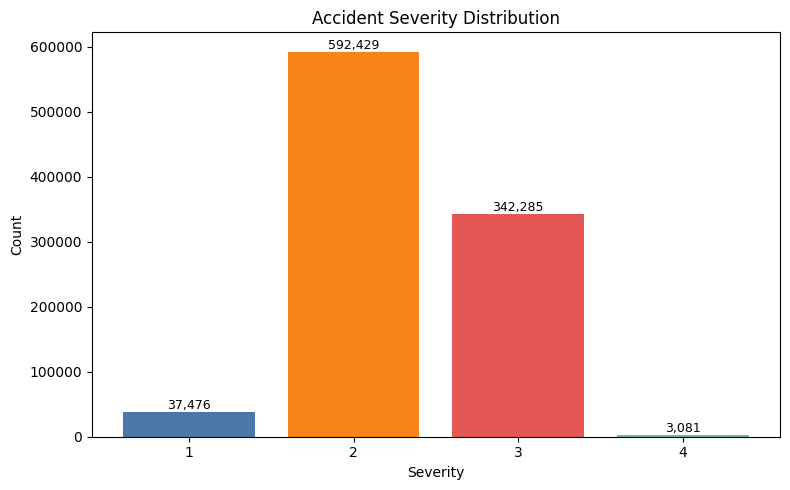

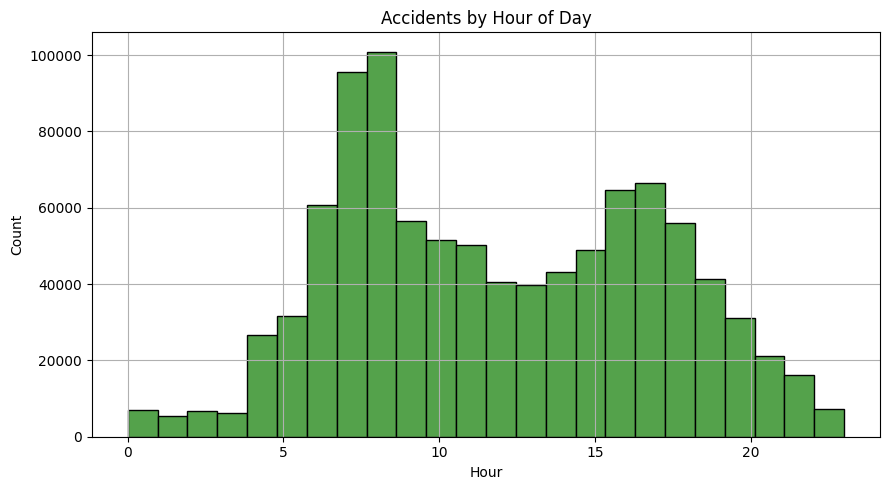

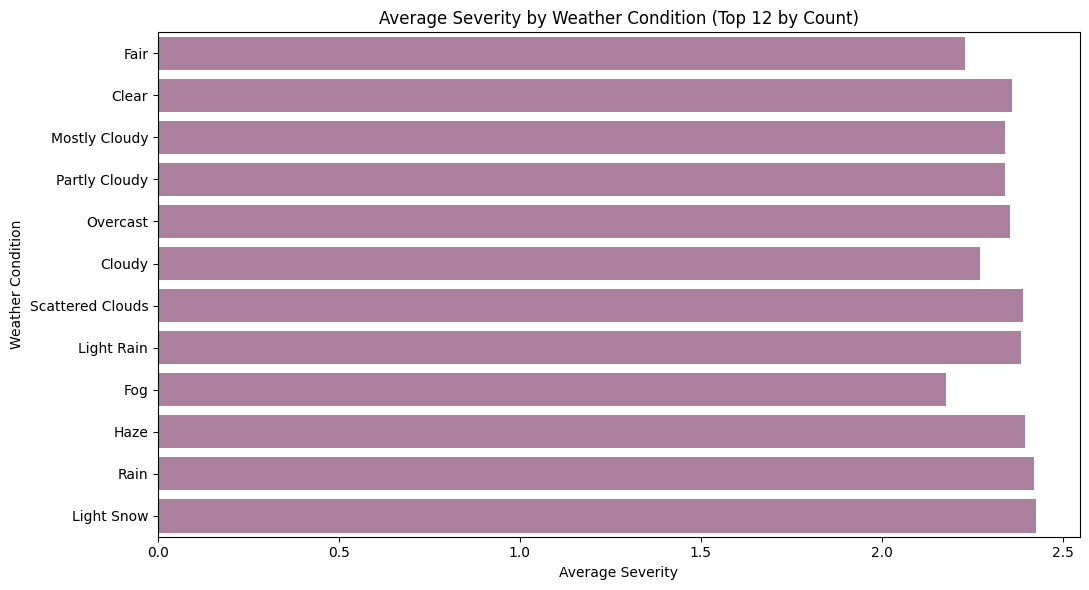

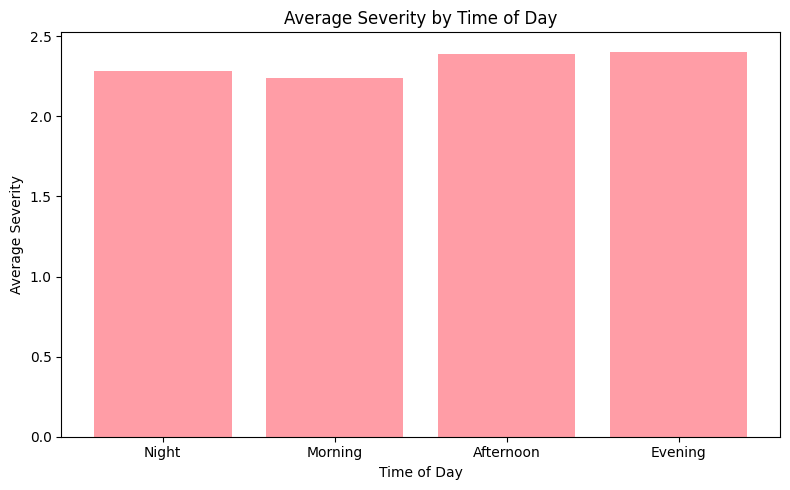

In [26]:
# visualization libraries
import plotly.express as px

# limit mapping to subset of columns
map_cols = ['Start_Lat', 'Start_Lng', 'Severity', 'State', 'City']
map_df = analysis_df.loc[:, map_cols].dropna(subset=['Start_Lat', 'Start_Lng'])
viz_sample = map_df.sample(n=min(25000, len(map_df)), random_state=42)

# 1) severity distribution
fig, ax = plt.subplots(figsize=(8, 5))
severity_order = analysis_df['Severity'].value_counts().sort_index()
ax.bar(severity_order.index.astype(str), severity_order.values, color=['#4c78a8', '#f58518', '#e45756', '#72b7b2'])
ax.set_title('Accident Severity Distribution')
ax.set_xlabel('Severity')
ax.set_ylabel('Count')
for i, value in enumerate(severity_order.values):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 2) hour of day histogram
fig, ax = plt.subplots(figsize=(9, 5))
analysis_df['Hour'].dropna().hist(bins=24, ax=ax, color='#54a24b', edgecolor='black')
ax.set_title('Accidents by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# 3) weather condition vs severity (top conditions by count)
if 'Weather_Condition' in analysis_df.columns:
    weather_plot = (
        analysis_df.groupby('Weather_Condition')
        .agg(count=('Severity', 'size'), mean_severity=('Severity', 'mean'))
        .sort_values('count', ascending=False)
        .head(12)
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.barplot(data=weather_plot, x='mean_severity', y='Weather_Condition', ax=ax, color='#b279a2')
    ax.set_title('Average Severity by Weather Condition (Top 12 by Count)')
    ax.set_xlabel('Average Severity')
    ax.set_ylabel('Weather Condition')
    plt.tight_layout()
    plt.show()

# 4) time of day comparison
fig, ax = plt.subplots(figsize=(8, 5))
time_plot = analysis_df.groupby('TimeOfDay')['Severity'].mean().reindex(['Night', 'Morning', 'Afternoon', 'Evening'])
ax.bar(time_plot.index.astype(str), time_plot.values, color='#ff9da6')
ax.set_title('Average Severity by Time of Day')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Average Severity')
plt.tight_layout()
plt.show()

# 5) map of accidents across the US using a sampled subset
us_map = px.scatter_mapbox(
    viz_sample,
    lat='Start_Lat',
    lon='Start_Lng',
    color='Severity',
    color_continuous_scale='Turbo',
    zoom=3,
    height=650,
    title='US Traffic Accidents Map (Sampled Points)',
    mapbox_style='open-street-map',
    hover_data=['State', 'City', 'Severity']
)
us_map.update_layout(margin={'r':0, 't':50, 'l':0, 'b':0})
us_map.show()

# 6) Indiana + Kentucky closer view
in_ky = viz_sample[viz_sample['State'].isin(['IN', 'KY'])].copy()
if not in_ky.empty:
    in_ky_map = px.scatter_mapbox(
        in_ky,
        lat='Start_Lat',
        lon='Start_Lng',
        color='Severity',
        color_continuous_scale='Turbo',
        zoom=6,
        center={'lat': 38.9, 'lon': -85.3},
        height=650,
        title='Traffic Accidents in Indiana and Kentucky (Sampled Points)',
        mapbox_style='open-street-map',
        hover_data=['State', 'City', 'Severity']
    )
    in_ky_map.update_layout(margin={'r':0, 't':50, 'l':0, 'b':0})
    in_ky_map.show()
else:
    print('No Indiana/Kentucky records were found in the sample.')

## Part 11: Linear Regression Model

predict severity based on given features, and evaluate the model performance using appropriate metrics (e.g., R-squared, MAE, RMSE).

In [34]:
features = [
    'Temperature(F)',
    'Visibility(mi)',
    'Precipitation(in)',
    'Weather_Condition',
    'TimeOfDay',
    'Traffic_Signal',
    'Junction',
    'Stop',
    'Crossing',
    'IsWeekend',
]

target = 'Severity'

X = analysis_df[features]
y = analysis_df[target]

In [35]:
# split into train and test sets
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = [
    'Temperature(F)',
    'Visibility(mi)',
    'Precipitation(in)'
]

categorical_features = [
    'Weather_Condition',
    'TimeOfDay'
]

boolean_features = [
    'IsWeekend',
    'Junction',
    'Traffic_Signal',
    'Crossing',
    'Stop'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bool', 'passthrough', boolean_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [36]:
# train
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [37]:
# predictions
y_pred = model.predict(X_test)

In [38]:
# evaluate
from sklearn.metrics import r2_score, root_mean_squared_error


rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

evaluation_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}).reset_index(drop=True)
print("Model Evaluation Metrics")
print("=" * 60)
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

Model Evaluation Metrics
R-squared: 0.1323
RMSE: 0.5105


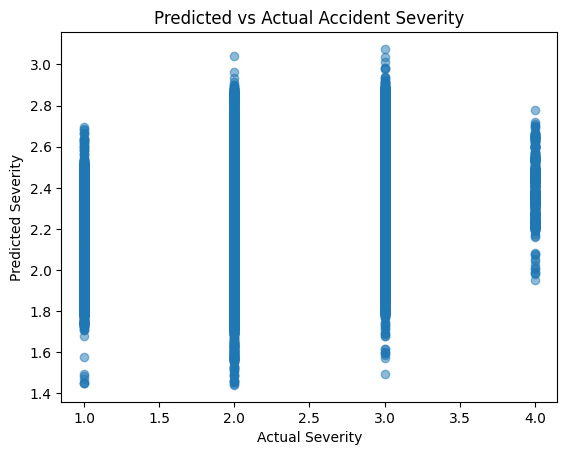

In [41]:
# visualize linear regression model predictions vs actuals
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title("Predicted vs Actual Accident Severity")
plt.xlabel("Actual Severity")
plt.ylabel("Predicted Severity")
plt.show()

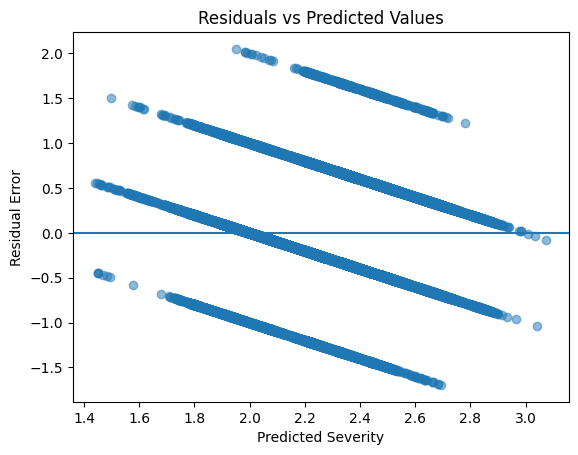

In [42]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Severity")
plt.ylabel("Residual Error")
plt.show()